In [38]:
import mne
import numpy as np
import pandas as pd
import os

from scipy.signal import welch
from scipy.stats import skew, kurtosis

# ================= PREPROCESSING =================
def preprocess_eeg(file_path):
    raw = mne.io.read_raw_edf(file_path, preload=True, verbose=False)

    # Rename channels
    mapping = {ch: ch.replace('EEG ', '').replace('-CPz', '').strip() for ch in raw.ch_names}
    raw.rename_channels(mapping)

    raw.pick("eeg")

    montage = mne.channels.make_standard_montage('standard_1020')
    raw.set_montage(montage, on_missing='ignore')

    raw.filter(0.1, 30, verbose=False)
    raw.notch_filter(50, verbose=False)

    raw.set_eeg_reference('average')

    return raw


# ================= EPOCHING =================
def get_epochs(raw):
    events, event_id = mne.events_from_annotations(raw)

    epochs = mne.Epochs(
        raw, events, event_id=event_id,
        tmin=-0.2, tmax=0.8,
        baseline=(None, 0),
        preload=True,
        event_repeated='merge',
        verbose=False
    )

    return epochs


# ================= BANDPOWER =================
def bandpower(signal, sf, band):
    freqs, psd = welch(signal, sf, nperseg=int(sf*2))
    idx = (freqs >= band[0]) & (freqs <= band[1])
    return np.trapz(psd[idx], freqs[idx])


# ================= FEATURE EXTRACTION =================
# ================= FEATURE EXTRACTION =================
def extract_features(epochs):
    important_channels = ['Pz', 'Cz', 'P3', 'P4']
    features = []

    sf = int(epochs.info['sfreq'])

    for trial in epochs.get_data():
        row = []

        for ch in important_channels:
            if ch in epochs.ch_names:
                idx = epochs.ch_names.index(ch)
                signal = trial[idx]
                times = epochs.times

                # -------- P300 WINDOW --------
                mask = (times >= 0.28) & (times <= 0.45)
                w_signal = signal[mask]
                w_time = times[mask]

                if len(w_signal) > 0:
                    peak_idx = np.argmax(w_signal)
                    amp = w_signal[peak_idx]
                    lat = w_time[peak_idx]
                else:
                    amp, lat = 0, 0

                # -------- TIME DOMAIN --------
                mean = np.mean(signal)
                std = np.std(signal)

                # -------- BANDPOWER --------
                delta = bandpower(signal, sf, (0.5, 4))
                theta = bandpower(signal, sf, (4, 8))
                alpha = bandpower(signal, sf, (8, 13))
                beta  = bandpower(signal, sf, (13, 30))

                # -------- ADL SCORE (COMPOSITE INDEX) --------
                adl = (alpha + beta) / (delta + theta + 1e-6)

                row.extend([
                    amp, lat,
                    mean, std,
                    delta, theta, alpha, beta,
                    adl
                ])

            else:
                row.extend([0]*9)

        features.append(row)

    return np.array(features), important_channels

# ================= PROCESS FOLDER =================
def process_folder(folder_path, label):
    X_all, y_all = [], []

    for file in os.listdir(folder_path):
        if file.endswith(".edf"):
            path = os.path.join(folder_path, file)
            print("Processing:", file)

            try:
                raw = preprocess_eeg(path)
                epochs = get_epochs(raw)

                for key in epochs.event_id.keys():
                    X, channels = extract_features(epochs[key])

                    if len(X) == 0:
                        continue

                    X_all.extend(X)
                    y_all.extend([label]*len(X))

            except Exception as e:
                print("Error:", file, e)

    return np.array(X_all), np.array(y_all), channels


# ================= RUN TBI =================
tbi_folder = r"E:\aditi_eeg\visual_eeg\tbi"

X_tbi, y_tbi, channels = process_folder(tbi_folder, label=1)

print("TBI Shape:", X_tbi.shape)

Processing: p1_auditory_2026-04-07_10-02-16_Segment_0.edf
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Used Annotations descriptions: ['Condition Baseline End  EpochE', 'Condition Baseline Start  EpochE', 'Condition Task_End  EpochE', 'Condition Task_Start  EpochE', 'Condition non target  EpochE', 'Condition target  EpochE', 'EventCode 1002  EpochE', 'EventCode 1003  EpochE', 'EventCode 1004  EpochE', 'EventCode 1005  EpochE', 'EventCode 1006  EpochE', 'EventCode 1007  EpochE', 'Impedance']


C:\Users\HP\AppData\Local\Temp\ipykernel_262284\3816713125.py:61: RuntimeWarning: epochs._get_data() can't run because this Epochs-object is empty. You might want to check Epochs.drop_log or Epochs.plot_drop_log() to see why epochs were dropped.
  for trial in epochs.get_data():
C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\scipy\signal\_spectral_py.py:600: UserWarning: nperseg = 2048 is greater than input length  = 1025, using nperseg = 1025
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,


Processing: p1_a_2026-04-06_11-41-22_Segment_0.edf
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Used Annotations descriptions: ['Condition Baseline End  EpochE', 'Condition Baseline Start  EpochE', 'Condition Task_End  EpochE', 'Condition Task_Start  EpochE', 'Condition non target  EpochE', 'Condition target  EpochE', 'EventCode 1002  EpochE', 'EventCode 1003  EpochE', 'EventCode 1004  EpochE', 'EventCode 1005  EpochE', 'EventCode 1006  EpochE', 'EventCode 1007  EpochE', 'Impedance']


C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\scipy\signal\_spectral_py.py:600: UserWarning: nperseg = 2048 is greater than input length  = 1025, using nperseg = 1025
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,


Processing: p1_a_2026-04-06_12-03-27_Segment_0.edf
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Used Annotations descriptions: ['Condition Baseline End  EpochE', 'Condition Baseline Start  EpochE', 'Condition Task_End  EpochE', 'Condition Task_Start  EpochE', 'Condition non target  EpochE', 'Condition target  EpochE', 'EventCode 1002  EpochE', 'EventCode 1003  EpochE', 'EventCode 1004  EpochE', 'EventCode 1005  EpochE', 'EventCode 1006  EpochE', 'EventCode 1007  EpochE', 'Impedance']


...

Processing: p6_visual_2026-04-06_12-52-05_Segment_0.edf
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Used Annotations descriptions: ['Condition Baseline End  EpochE', 'Condition Baseline Start  EpochE', 'Condition Task_End  EpochE', 'Condition Task_Start  EpochE', 'Condition non target  EpochE', 'Condition target  EpochE', 'EventCode 1002  EpochE', 'EventCode 1003  EpochE', 'EventCode 1004  EpochE', 'EventCode 1005  EpochE', 'EventCode 1006  EpochE', 'EventCode 1007  EpochE', 'Impedance']


C:\Users\HP\AppData\Local\Temp\ipykernel_262284\3816713125.py:61: RuntimeWarning: epochs._get_data() can't run because this Epochs-object is empty. You might want to check Epochs.drop_log or Epochs.plot_drop_log() to see why epochs were dropped.
  for trial in epochs.get_data():
C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\scipy\signal\_spectral_py.py:600: UserWarning: nperseg = 2048 is greater than input length  = 1025, using nperseg = 1025
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,


Processing: p7_visual_2026-04-06_12-59-46_Segment_0.edf
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Used Annotations descriptions: ['Condition Baseline End  EpochE', 'Condition Baseline Start  EpochE', 'Condition Task_End  EpochE', 'Condition Task_Start  EpochE', 'Condition non target  EpochE', 'Condition target  EpochE', 'EventCode 1002  EpochE', 'EventCode 1003  EpochE', 'EventCode 1004  EpochE', 'EventCode 1005  EpochE', 'EventCode 1006  EpochE', 'EventCode 1007  EpochE', 'Impedance']


C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\scipy\signal\_spectral_py.py:600: UserWarning: nperseg = 2048 is greater than input length  = 1025, using nperseg = 1025
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,


TBI Shape: (1703, 36)


In [39]:
## ================= COLUMN NAMES =================

columns = []

feature_names = [
    "amp", "lat",
    "mean", "std",
    "delta", "theta", "alpha", "beta",
    "adl_score"
]

for ch in channels:
    for f in feature_names:
        columns.append(f"{ch}_{f}")


# ================= CREATE DATAFRAME =================

import pandas as pd
import os
import numpy as np

df = pd.DataFrame(X_tbi, columns=columns)
df["Label"] = y_tbi


# ================= SAVE PATH =================

save_path = r"E:\aditi_eeg\visual_eeg\tbi_visual"
os.makedirs(save_path, exist_ok=True)


# ================= SAVE FILES =================

df.to_excel(os.path.join(save_path, "dataset.xlsx"), index=False)
df.to_csv(os.path.join(save_path, "dataset.csv"), index=False)

np.save(os.path.join(save_path, "X.npy"), X_tbi)
np.save(os.path.join(save_path, "y.npy"), y_tbi)


# ================= PRINT =================

print("TBI files saved")
print("Shape:", X_tbi.shape)
print("Labels:", np.unique(y_tbi))

TBI files saved
Shape: (1703, 36)
Labels: [1]


In [40]:
print("X shape:", X_tbi.shape)
print("Expected columns:", len(channels) * len(feature_names))

X shape: (1703, 36)
Expected columns: 36


In [46]:
# ================= PRINT DATA INFO =================

print("Column Names:")
print(df.columns)

print("\nNumber of Columns:", df.shape[1])
print("Number of Rows:", df.shape[0])

print("\nFirst 5 Rows:")
print(df.head())

Column Names:
Index(['Pz_amp', 'Pz_lat', 'Pz_mean', 'Pz_std', 'Pz_delta', 'Pz_theta',
       'Pz_alpha', 'Pz_beta', 'Pz_adl_score', 'Cz_amp', 'Cz_lat', 'Cz_mean',
       'Cz_std', 'Cz_delta', 'Cz_theta', 'Cz_alpha', 'Cz_beta', 'Cz_adl_score',
       'P3_amp', 'P3_lat', 'P3_mean', 'P3_std', 'P3_delta', 'P3_theta',
       'P3_alpha', 'P3_beta', 'P3_adl_score', 'P4_amp', 'P4_lat', 'P4_mean',
       'P4_std', 'P4_delta', 'P4_theta', 'P4_alpha', 'P4_beta', 'P4_adl_score',
       'Label'],
      dtype='object')

Number of Columns: 37
Number of Rows: 1703

First 5 Rows:
         Pz_amp    Pz_lat       Pz_mean    Pz_std      Pz_delta      Pz_theta  \
0  5.331668e-05  0.394531  3.513937e-05  0.000025  1.203070e-10  1.801561e-13   
1  7.197222e-06  0.393555  1.329427e-08  0.000004  1.406815e-11  3.028868e-12   
2 -1.601801e-07  0.280273 -3.630325e-07  0.000006  2.114896e-11  2.573272e-12   
3 -1.295794e-06  0.297852 -5.194043e-06  0.000006  1.164307e-11  1.343342e-12   
4 -5.381216e-06  0.445312

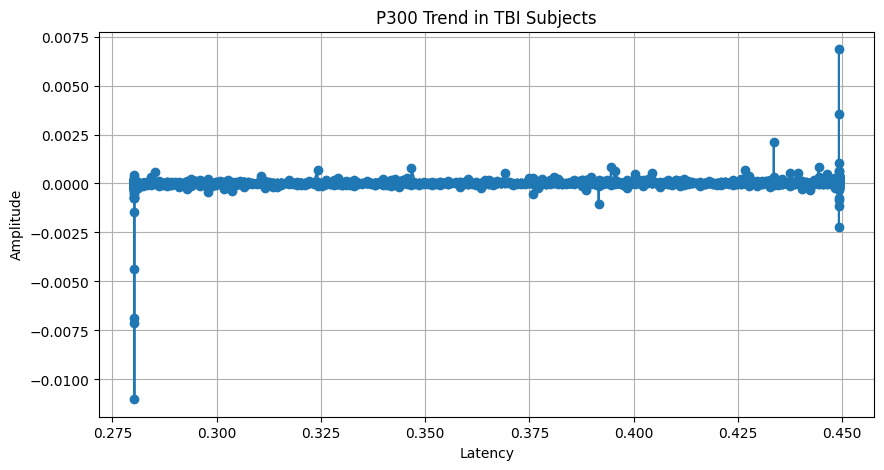

In [41]:
sorted_idx = np.argsort(tbi_lat)
sorted_lat = tbi_lat[sorted_idx]
sorted_amp = tbi_amp[sorted_idx]

plt.figure(figsize=(10,5))
plt.plot(sorted_lat, sorted_amp, marker='o')

plt.title("P300 Trend in TBI Subjects")
plt.xlabel("Latency")
plt.ylabel("Amplitude")
plt.grid()
plt.show()

EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Used Annotations descriptions: ['Condition Baseline End  EpochE', 'Condition Baseline Start  EpochE', 'Condition Task_End  EpochE', 'Condition Task_Start  EpochE', 'Condition non target  EpochE', 'Condition target  EpochE', 'EventCode 1002  EpochE', 'EventCode 1003  EpochE', 'EventCode 1004  EpochE', 'EventCode 1005  EpochE', 'EventCode 1006  EpochE', 'EventCode 1007  EpochE', 'Impedance']
✔ EEG loaded
Using channel: Pz


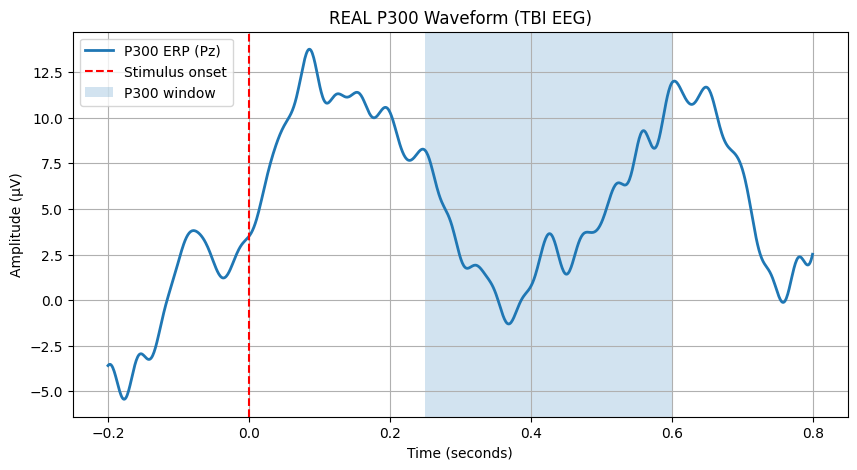

In [45]:
import mne
import numpy as np
import matplotlib.pyplot as plt

# ================= FILE =================
file_path = r"E:\aditi_eeg\visual_eeg\tbi\p7_visual_2026-04-06_12-59-46_Segment_0.edf"

# ================= PREPROCESS =================
raw = preprocess_eeg(file_path)
epochs = get_epochs(raw)

print("✔ EEG loaded")

# ================= FIND Pz =================
channel = [ch for ch in epochs.ch_names if "Pz" in ch][0]
idx = epochs.ch_names.index(channel)

print("Using channel:", channel)

# ================= DATA =================
data = epochs.get_data()[:, idx, :]   # (trials × time)

# remove noisy trials (IMPORTANT)
data = data[np.std(data, axis=1) < np.percentile(np.std(data, axis=1), 90)]

# ================= ERP =================
erp = np.mean(data, axis=0)
t = epochs.times

# baseline correction (VERY IMPORTANT)
erp = erp - np.mean(erp[t < 0])

# ================= PLOT P300 =================
plt.figure(figsize=(10,5))

plt.plot(t, erp * 1e6, linewidth=2, label="P300 ERP (Pz)")

plt.axvline(0, color="red", linestyle="--", label="Stimulus onset")

plt.axvspan(0.25, 0.60, alpha=0.2, label="P300 window")

plt.title("REAL P300 Waveform (TBI EEG)")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude (µV)")
plt.legend()
plt.grid()

plt.show()